In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Load the file
df = pd.read_excel('heart_disease.xlsx')

# Verify the load
print("Data loaded! Here are the columns:")
print(df.columns.tolist())

Data loaded! Here are the columns:
['date', 'country', 'id', 'active', 'age', 'alco', 'ap_hi', 'ap_lo', 'cholesterol', 'gender', 'gluc', 'height', 'occupation', 'smoke', 'weight', 'disease']


In [3]:
# Drop non-predictive columns
cols_to_drop = ['date', 'country', 'id', 'occupation']
df_clean = df.drop(cols_to_drop, axis=1, errors='ignore')

# Check if there are any missing values
print("Missing values per column:\n", df_clean.isnull().sum())

Missing values per column:
 active         0
age            0
alco           0
ap_hi          0
ap_lo          0
cholesterol    0
gender         0
gluc           0
height         0
smoke          0
weight         0
disease        0
dtype: int64


In [4]:
# Define Features (X) and Target (y)
X = df_clean.drop('disease', axis=1)
y = df_clean['disease']

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data split successfully!")

Data split successfully!


In [5]:
# Train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Show performance
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.75      0.72      6988
           1       0.73      0.67      0.70      7012

    accuracy                           0.71     14000
   macro avg       0.71      0.71      0.71     14000
weighted avg       0.71      0.71      0.71     14000



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


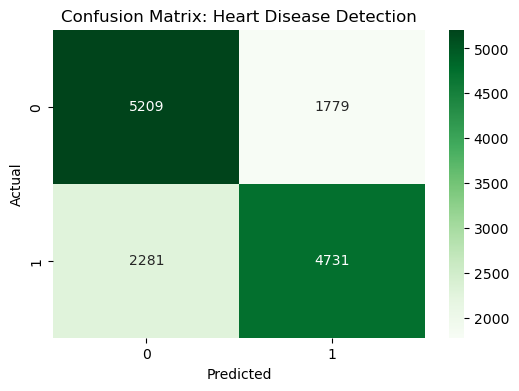

In [8]:
# Plot the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix: Heart Disease Detection")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()